# 6 · The keep/revert loop

Now we close the loop. `harness/loop.py` proposes a change, trains under budget,
scores with the immutable evaluator, and **keeps the change only if the score
improved** — otherwise it reverts. Every attempt, kept or not, is appended to
`results.tsv`. The built-in `SearchProposer` stands in for the LLM agent.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # make `harness` importable
import matplotlib
matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    print("building a small bdd-tiny ...")
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA)

dataset: ../data/bdd-tiny.lance


In [2]:
from harness.loop import run_loop
out = run_loop(iters=8, dataset_path=str(DATA), results_path="results.tsv", verbose=True)
print("\nbest score:", round(out["best_score"], 4))

[iter 0] baseline score=0.883 worst=0.644(foggy)


[iter 1] KEEP score=0.972 (best=0.972) worst=0.733(foggy) :: Fog is the worst, rarest slice -> upweight fog frames 5x.


[iter 2] KEEP score=0.975 (best=0.975) worst=0.733(foggy) :: Expand fog upweighting to LanceDB nearest neighbours (fog-like frames).


[iter 3] KEEP score=1.018 (best=1.018) worst=0.778(foggy) :: Give the net more capacity to fit the weak fog signal.


[iter 4] revert score=0.951 (best=1.018) worst=0.711(foggy) :: Spend more of the budget on epochs to extract the weak fog cue.


[iter 5] KEEP score=1.019 (best=1.019) worst=0.778(foggy) :: Add weight decay to denoise the high-variance fog frames.


[iter 6] revert score=0.974 (best=1.019) worst=0.733(foggy) :: Label smoothing to stop overconfidence on noisy fog labels.


[iter 7] revert score=0.928 (best=1.019) worst=0.689(foggy) :: Horizontal flip: cheap, label-preserving augmentation.


[iter 8] revert score=0.974 (best=1.019) worst=0.733(foggy) :: Cosine LR decay for a cleaner final convergence.

best score: 1.019


### The score trajectory — and the immutability guard that protects it

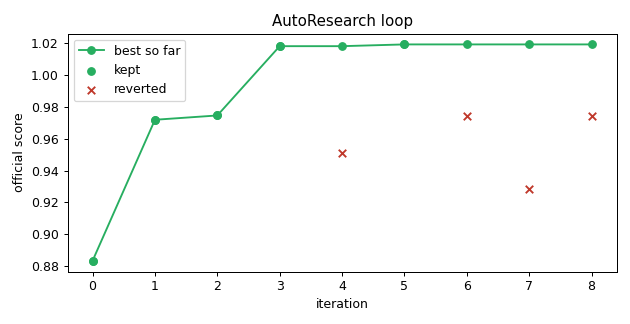

In [3]:
import csv
rows = list(csv.DictReader(open("results.tsv"), delimiter="\t"))
its = [int(r["iter"]) for r in rows]
score = [float(r["score"]) for r in rows]
best = [float(r["best_so_far"]) for r in rows]
kept = [r["kept"] == "True" for r in rows]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(its, best, "-o", color="#27ae60", label="best so far")
ax.scatter([i for i, k in zip(its, kept) if k], [s for s, k in zip(score, kept) if k],
           color="#27ae60", zorder=3, label="kept")
ax.scatter([i for i, k in zip(its, kept) if not k], [s for s, k in zip(score, kept) if not k],
           color="#c0392b", marker="x", zorder=3, label="reverted")
ax.set_xlabel("iteration"); ax.set_ylabel("official score"); ax.set_title("AutoResearch loop")
ax.legend(); fig.tight_layout(); fig.savefig("fig_06_loop.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_06_loop.png")

### The guard in action — you cannot win by editing the ruler

In [4]:
from harness.loop import snapshot_immutable, verify_immutable
snap = snapshot_immutable()
verify_immutable(snap)                      # clean: passes
tampered = dict(snap); tampered["harness/evaluator.py"] = "0" * 64
try:
    verify_immutable(tampered)
except RuntimeError as e:
    print("REJECTED:", e)

REJECTED: immutable files changed during the iteration; score rejected: harness/evaluator.py


The green line never goes down: a change is only kept when it beats the best.
The red X's are reverted experiments — dead ends the agent tried and abandoned.
And if any protected file changes mid-iteration, the score is thrown out.